##IMPORTATION DES DÉPENDANCES

###Machine Learning

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.model_selection import train_test_split, LearningCurveDisplay, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

## CHARGEMENT DU DATASET

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/creditcard.csv')

##COMPRÉHENSION DU PROBLÈME

##COMPRÉHENSION DES DONNÉES ET TRAITEMENT

In [ ]:
# Dimensions du dataset
df.shape

(284807, 31)

In [ ]:
# Affichage des 5 premières lignes
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# Affichage aléatoire de 10 lignes du dataset
df.sample(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
861,654.0,-0.878153,-0.225125,1.928062,-2.621671,0.051866,-0.127212,-0.278676,0.464785,0.956588,...,0.237521,0.618994,-0.076144,-0.275215,-0.323064,-0.180814,0.121570,0.106821,0.05,0
137895,82378.0,1.152442,0.047389,1.307477,1.332619,-0.883448,-0.173668,-0.484411,0.028230,0.724317,...,-0.049322,0.116819,-0.017956,0.426276,0.452056,-0.413031,0.079573,0.040823,9.99,0
127281,78275.0,1.177503,-0.009518,0.516208,0.040892,-0.622007,-0.866423,-0.044540,-0.139428,-0.202441,...,-0.036090,-0.157383,0.042017,0.611462,0.170387,0.867247,-0.083108,0.004362,31.35,0
75765,56241.0,1.367995,-0.832931,0.249661,-1.188355,-0.397251,1.075728,-1.176927,0.295871,-0.627328,...,0.366688,0.998198,-0.324586,-1.638728,0.565254,0.065559,0.047286,-0.000170,34.00,0
260218,159454.0,1.658222,-0.596803,-0.702951,1.235138,0.425267,1.783027,-0.482446,0.552819,0.946992,...,-0.386659,-0.916341,0.363525,-1.712707,-0.508272,-1.001385,0.085132,-0.044000,85.34,0
198732,132628.0,-1.163599,1.650752,-1.235375,-1.469595,1.129367,-0.990825,1.474717,-1.311170,0.462653,...,0.899514,0.600829,-0.150079,-0.467433,-0.205581,0.070921,0.315592,0.239477,19.26,0
234589,148033.0,-1.501197,0.482647,1.939166,0.881938,-0.201387,0.470977,-0.508311,0.886026,-0.313747,...,0.156785,0.238090,-0.237135,-0.433240,0.394991,-0.430564,0.250102,-0.005781,45.00,0
256431,157690.0,2.105699,-0.096734,-1.646378,-0.071226,0.753233,0.162771,0.041102,-0.055834,0.254505,...,-0.307434,-0.794361,0.223205,-0.335629,-0.146090,0.209132,-0.077160,-0.072713,1.98,0
40606,40314.0,-0.898783,0.518105,2.074105,1.620445,-0.588346,0.484509,-0.221593,0.542668,0.766546,...,-0.263262,-0.315798,0.144305,0.392727,-0.623161,-0.577973,-0.164620,-0.118146,11.98,0
284346,172359.0,-0.178989,1.122403,-1.059348,-0.819786,1.051395,0.049140,0.521855,0.440992,-0.359915,...,0.383386,1.176397,-0.191977,-0.316178,-0.639706,-0.203967,0.374640,0.245712,0.99,0


In [ ]:
# Quelques informations sur le dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Les types des données rassure pour ce qui est de la cohérence au sein des modalités des différentes variables

In [ ]:
# Statistique Descriptive
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [ ]:
# Vérification de la présence de valeurs manquantes
df.isna().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


Nous remarquons qu'il n'y a pas de valeurs manquantes

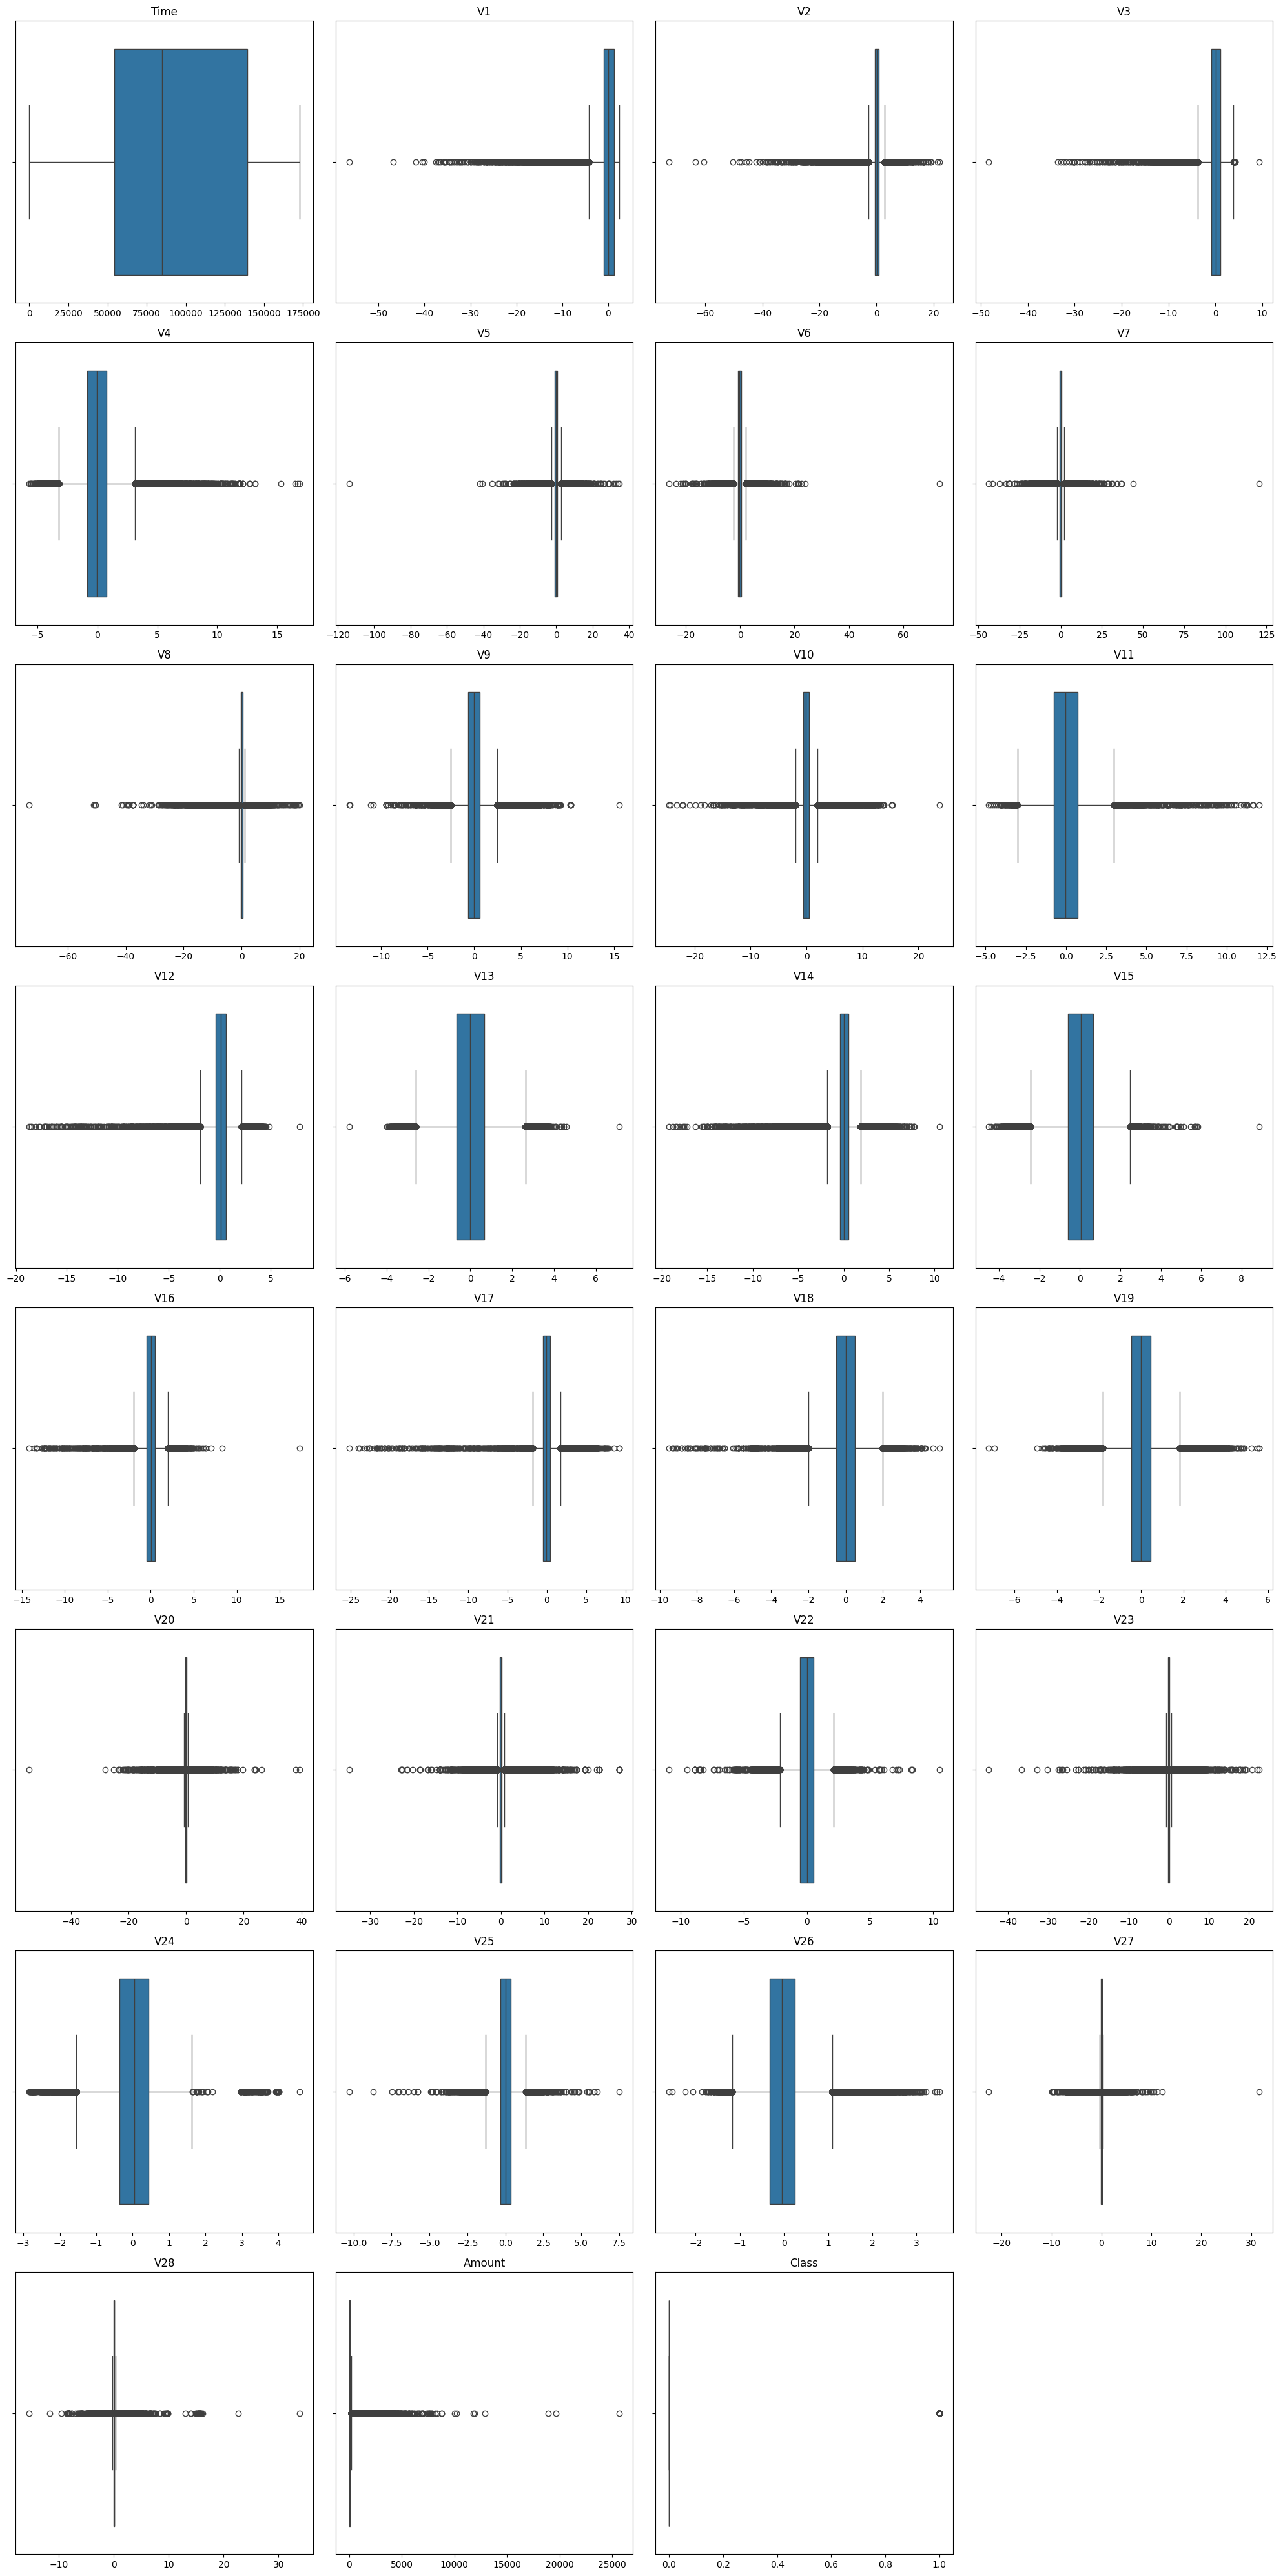

In [ ]:
# Visualisation des boxplots pour vérifier la présence d'outliers

num_cols = len(df.columns)
num_cols_per_row = 4
num_rows = (num_cols + num_cols_per_row - 1) // num_cols_per_row

fig, axes = plt.subplots(num_rows, num_cols_per_row, figsize=(20, 5 * num_rows))
axes = axes.flatten()

for i, colonne in enumerate(df.columns):
    sns.boxplot(x=df[colonne], ax=axes[i])
    axes[i].set_title(colonne)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Nous remarquons qu'en dehors de la varibale `Time`, toutes les autres variables possèdent des outliers, et ces outliers sont en très grand nombre pour la plupart.

Nous allons gérer les outliers en utilisant la racine cubique. En effet nous ne pouvons pas utilisé le logarithme en raison de la présence de modalités de signes nuls ou négatifs. Aussi nous ne pouvons pas supprimer les lignes contenant les outliers au risque de réduire totalement la taille du dataset en raison du grand nombre d'outliers. Mais aussi, il n'y a pas possibilité de réaliser un capping en utilisant la méthode IQR au risque d'influencer grandement la distribution des variables.

In [ ]:
# Création d'une copie avant transformation
df_copy=df

In [ ]:
# Transformation avec racine cubique
df_=df.drop(columns=['Class','Time'],axis=1)
transformer = FunctionTransformer(np.cbrt)
data_ = transformer.fit_transform(df_)

In [ ]:
# Reconstruction du dataset
c=df[['Class','Time']]
df = pd.concat([data_,c], axis=1)

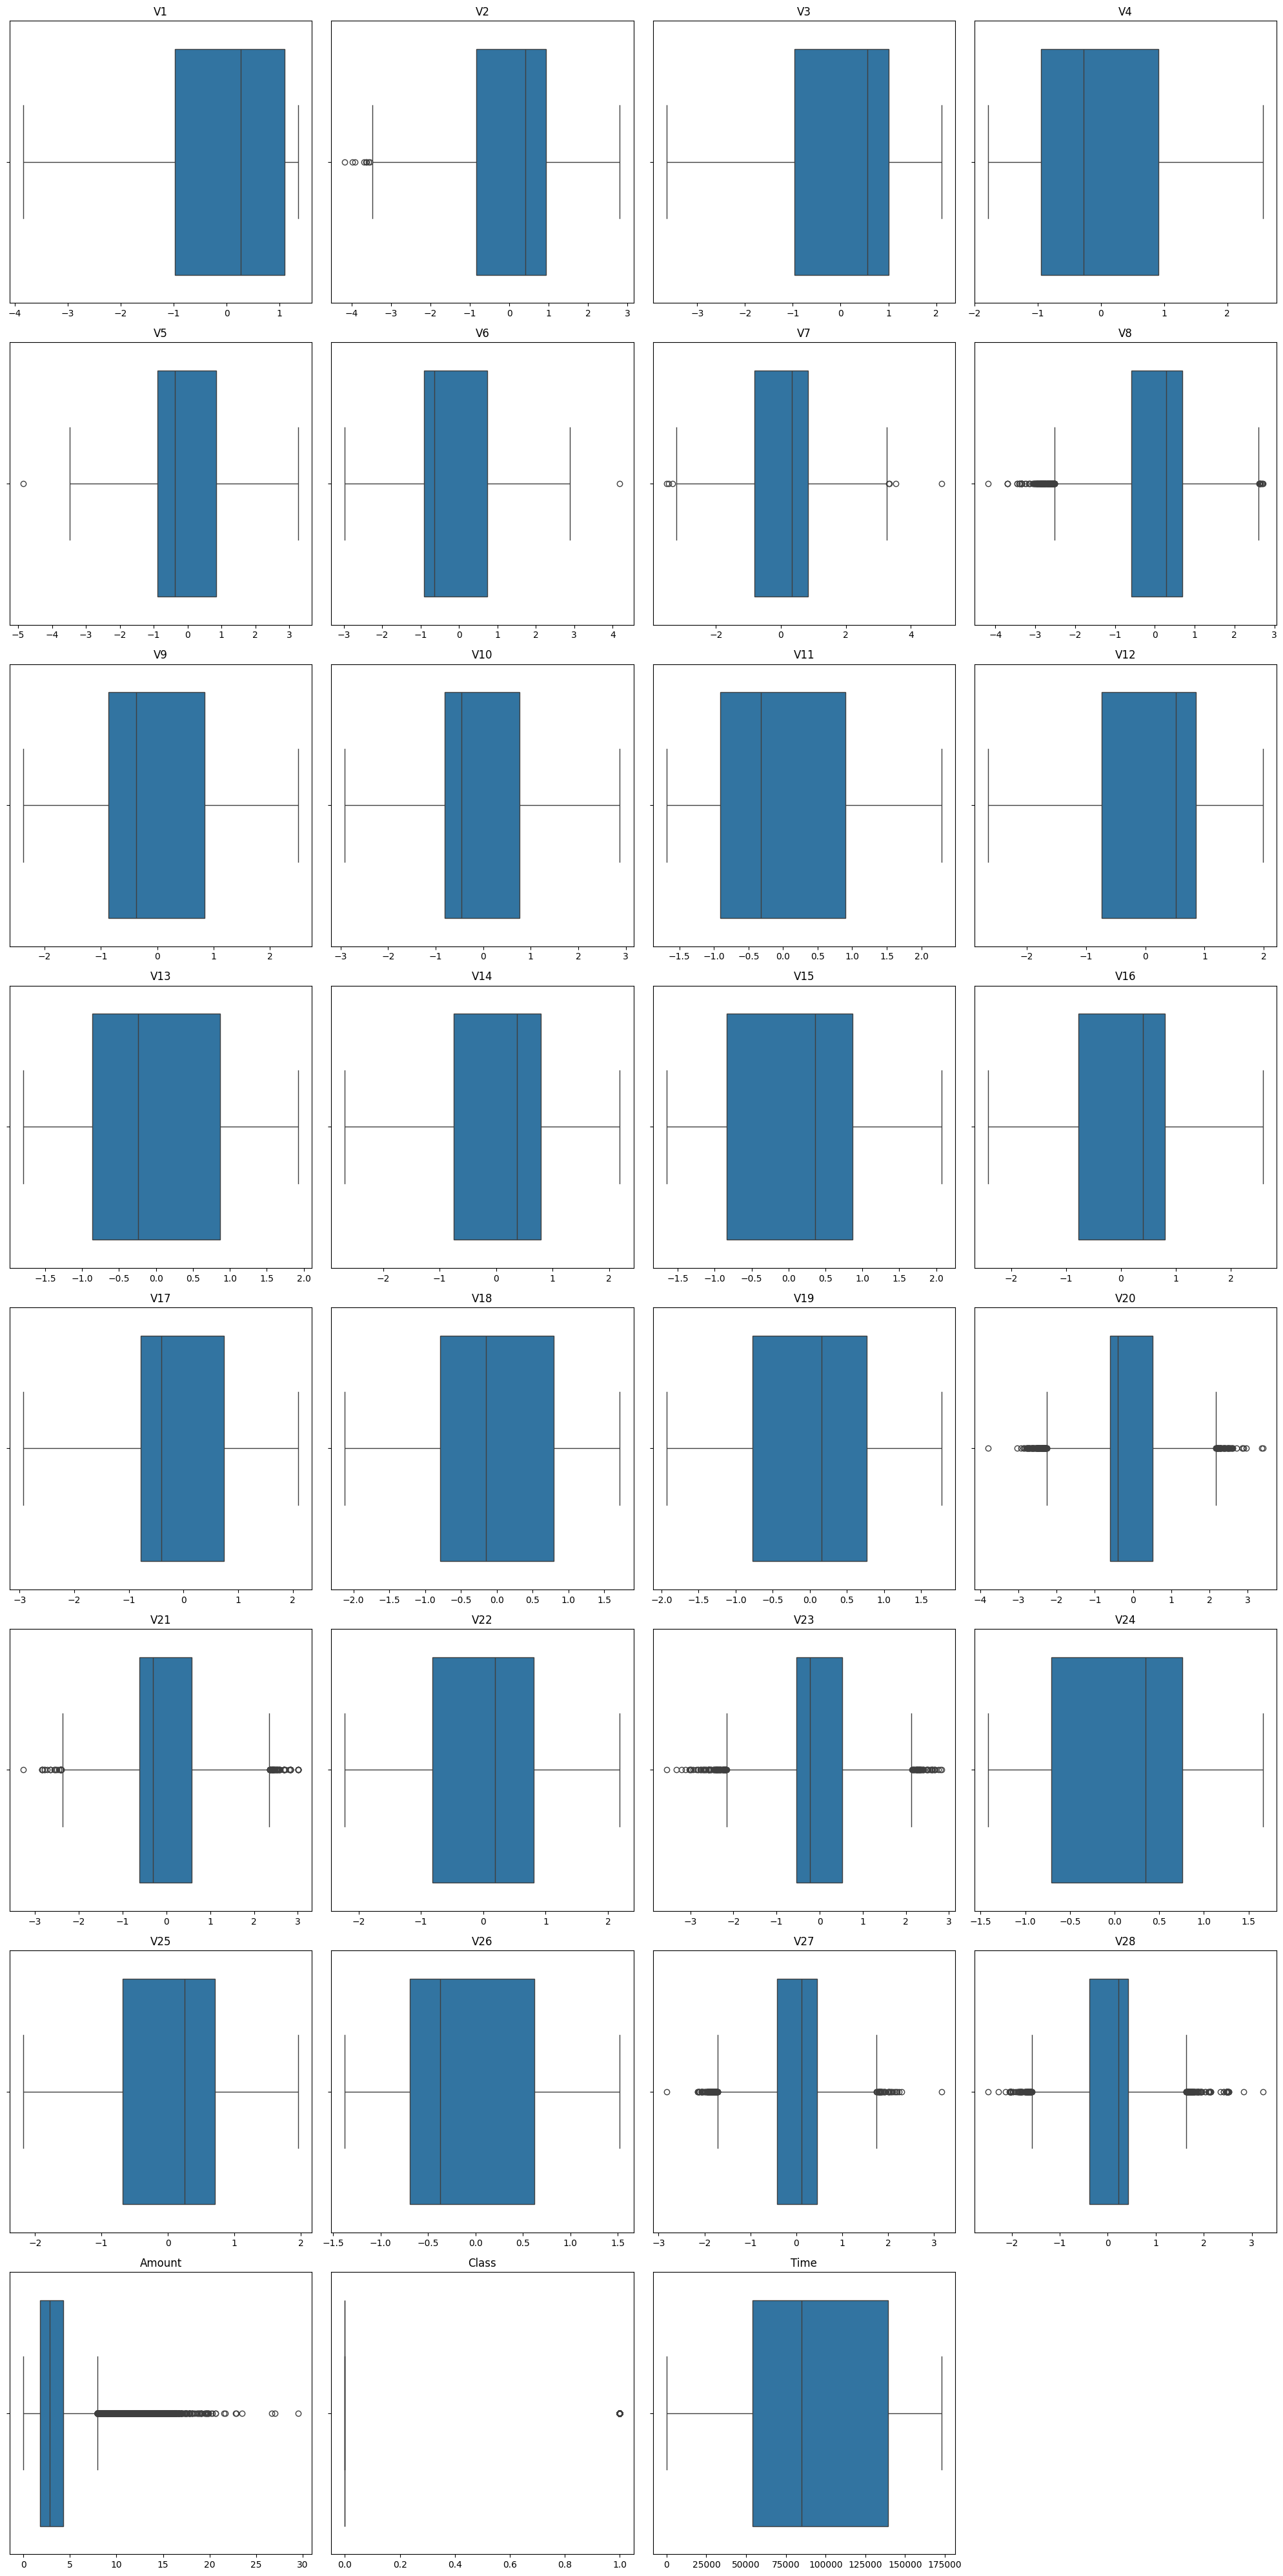

In [ ]:
# Vérification
num_cols = len(df.columns)
num_cols_per_row = 4
num_rows = (num_cols + num_cols_per_row - 1) // num_cols_per_row

fig, axes = plt.subplots(num_rows, num_cols_per_row, figsize=(20, 5 * num_rows))
axes = axes.flatten()

for i, colonne in enumerate(df.columns):
    sns.boxplot(x=df[colonne], ax=axes[i])
    axes[i].set_title(colonne)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

On remarque une diminution considérable des outliers. Cependant on remarque encore la présence d'autres outliers. Vue que nous ne connaissons pas les noms des variables pour comprendre leurs signification, nous ne sommes pas en mesure de décider de faire un capping en utilisant la méthode IQR pour celles qui n'ont plus trop de valeurs manquantes. Nous décidons donc de les garder et d'essayer de faire les bons choix de métriques et d'algorithmes pour la suite. Pour ce qui est du reste des variables, nous nous trouvons dans l'obligation de les laisser pour ne pas risquer de perdre de l'information éssentielle. Prenons l'exemple de la colonne `Amount`, les grands montant ne traduisent pas un problème nécessairement puisque les banques ont aussi bien des clients particuliers(pour les petites transactions) que des entreprises, des grosses sociétés(grosses transactions).

Observation du déséquilibre des classes

In [ ]:
100*df['Class'].value_counts()/len(df)

,count
Class,
0,99.827251
1,0.172749


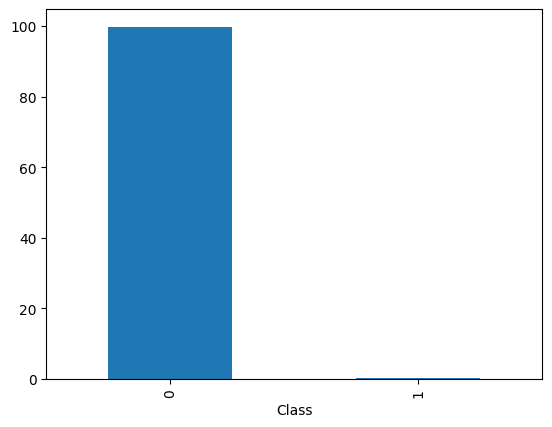

In [ ]:
(100*df['Class'].value_counts()/len(df)).plot(kind='bar');

In [ ]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


On remarque un très grand déséquilibre entre les classes. Moins de 1% pour la classe 1 (fraude), et plus de 99% pour la classe 0 (pas fraude). Vu l'écart entre les classes, si on décide de faire de l'augmentation de donnée que ce soit en duplicant des lignes de façon aléatoire, soit en faisant de la synthétisation avec SMOTE par exemple, le modèle risquera de faire de l'overfiting. L'écart ne permet pas non plus de faire de l'undersampling. C'est une classification binaire, on ne peut donc pas supprimer la classe 1 et on ne peut pas le fusionner avec une autre classe. Les solutions qui s'offrent à nous, c'est d'équilibrer les poids des classes, soit d'agir sur les seuils, soit de chercher un algorithme assez robuste pour supporter le déséquilibre(random forest, algorithme de détection d'anomalies, etc), et de faire des bons choix de métriques d'évaluation.

Analyse de la variable `montant`

In [ ]:
df_copy['Amount'].describe().transpose()

,Amount
count,284807.000000
mean,88.349619
std,250.120109
min,0.000000
25%,5.600000
50%,22.000000
75%,77.165000
max,25691.160000


In [ ]:
df['Amount'].describe().transpose()

,Amount
count,284807.000000
mean,3.253594
std,2.050051
min,0.000000
25%,1.775808
50%,2.802039
75%,4.257357
max,29.507193


Corrélation entre les variables

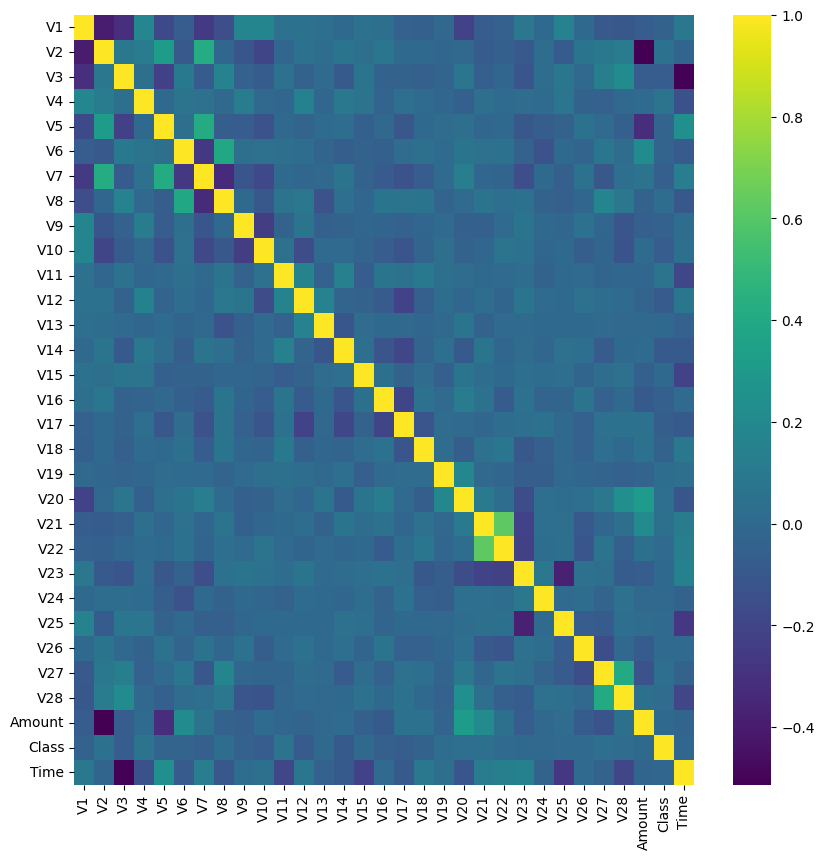

In [ ]:
# Matrice de corrélation entre les différentes variables
plt.figure(figsize=(10, 10))
sns.heatmap(df.corr(), cmap='viridis');

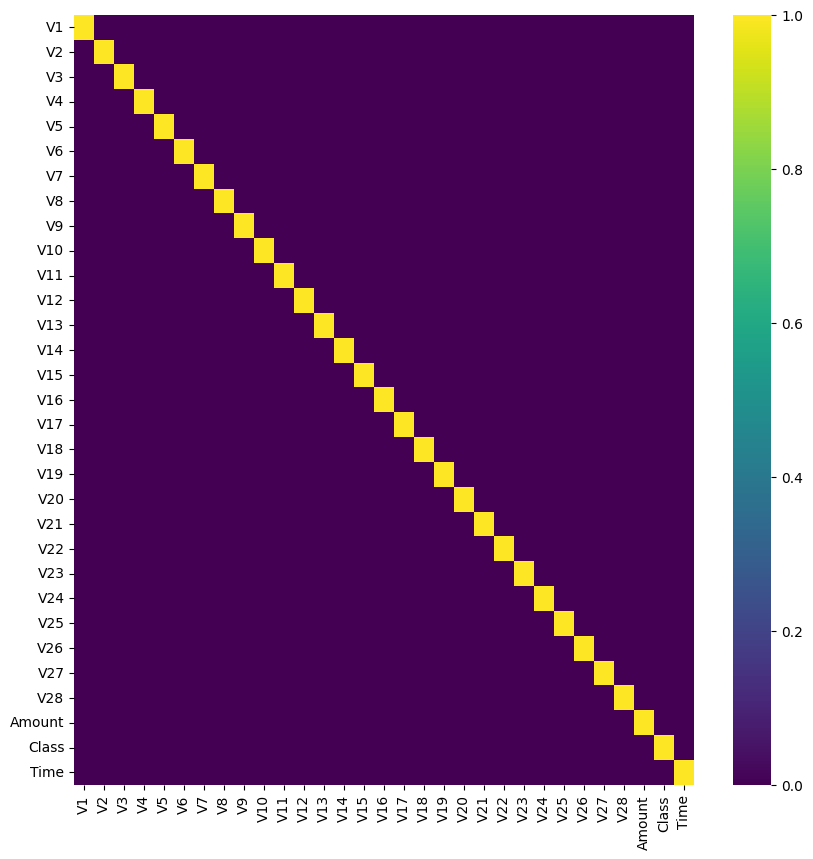

In [ ]:
# Avec un seuil de 90%
plt.figure(figsize=(10, 10))
sns.heatmap(df.corr()>0.9, cmap='viridis');

On remarque que les coéfficients de corrélation sont entre 0% et environ 10%. C'est un peu prévisible puisque le site précise que les variables sont des composantes principales issues d'un ACP.

## MODÉLISATION

###Découpage Et Standaraisation

In [ ]:
# Séparation et découpage des données
X=df.drop(columns=['Class'],axis=1)
y=df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


In [ ]:
# Standardisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


###Logistic Regression

In [ ]:
# modèle
log_reg = LogisticRegression()

In [ ]:
# grille de paramètres
param_grid = {'penalty':['l2', 'l1', 'elasticnet'],
              'class_weight':['balanced', 'None'],
              'random_state':[42],
              'C': [1, 100, 1000]}

In [ ]:
# modèle de validation croisée
grid = GridSearchCV(log_reg, param_grid, cv=5, verbose=1, n_jobs=-1)

In [ ]:
# entrainement
grid.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
75 fits failed out of a total of 90.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solver

GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [1, 100, 1000],
                         'class_weight': ['balanced', 'None'],
                         'penalty': ['l2', 'l1', 'elasticnet'],
                         'random_state': [42]},
             verbose=1)

In [ ]:
# les meilleurs paramètres
grid.best_params_

{'C': 100, 'class_weight': 'balanced', 'penalty': 'l2', 'random_state': 42}

In [ ]:
# le meilleur score
grid.best_score_

np.float64(0.9696133787677159)

In [ ]:
# prédiction
y_pred = grid.predict(X_test_scaled)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98     85295
           1       0.05      0.87      0.09       148

    accuracy                           0.97     85443
   macro avg       0.52      0.92      0.54     85443
weighted avg       1.00      0.97      0.98     85443



Parmi toutes les transactions qu'il a qualifié de frauduleuses, 5% le sont vraiment (precision 0.05).
Parmi les transactions qui sont vraiment fraudueleuses, il en a détecter 87% (recall 0.87).
Son score global pour les faudes est 9% (F1-score).

Pour ce qui est des transactions non frauduleuses, nous avons respectivement 100% 97% et 98% pour la précision, le recall, et le f1-score.  

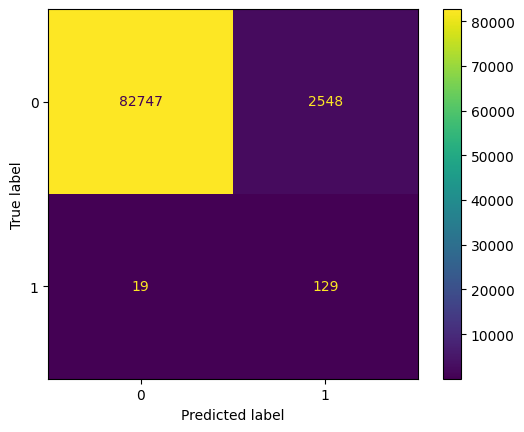

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred);

On comprend donc les métriques obtenues.

###Random Forest


In [ ]:
# modèle
rf = RandomForestClassifier(n_estimators=1000, class_weight='balanced',random_state=42)

In [ ]:
# entraînement
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=1000,
                       random_state=42)

In [ ]:
# prédiction
y_pred_rf = rf.predict(X_test)

In [ ]:
# métriques d'évaluation
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.97      0.70      0.82       148

    accuracy                           1.00     85443
   macro avg       0.99      0.85      0.91     85443
weighted avg       1.00      1.00      1.00     85443



On remarque une amélioration considérable au niveau des resultats. Que ce soit la précison, le rappel, ou le f1-score, on obtient le score de 100% pour les transactions non frauduleuses. Pour les transactions frauduleuses, on remarque que le modèle de Random Forest est nettement meilleur que la Regression Logistique. En effet on obtenait en Regression Logistique : précision: 5%, rappel: 87%, f1-score:9%, mais avec le Random Forest on est passé à respectivement: 97% 70% 82%. C'est nettement mieux, mais cherchons si on peut trouver un autre modèle qui fera mieux. Ce serait vraiment avantageux si le recall pourrait passer à un pourcentage élevé comme la précision. Avant cela, fouillons plus avec la matrice de confusion pour comprendre les résultats des métriques

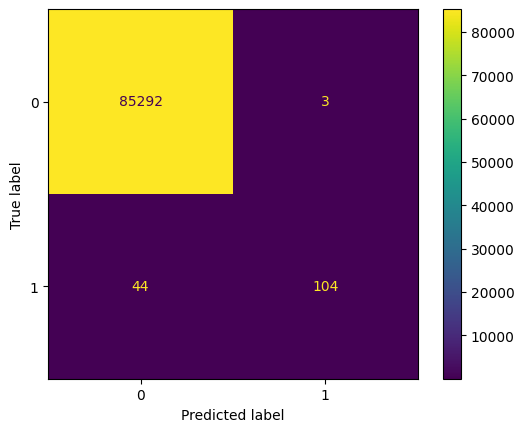

In [ ]:
# matrice de confusion
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf);

### XGBoostClassifier

In [ ]:
from xgboost import XGBClassifier

In [ ]:
grande_classe = df['Class'].value_counts()[0]
petite_classe = df['Class'].value_counts()[1]
pos_weight_value = grande_classe / petite_classe

print(f"Nombre d'échantillons de la grande classe (0): {grande_classe}")
print(f"Nombre d'échantillons de la classe positive (1): {petite_classe}")
print(f"Valeur calculée de pos_weight: {pos_weight_value}")

Nombre d'échantillons de la grande classe (0): 284315
Nombre d'échantillons de la classe positive (1): 492
Valeur calculée de pos_weight: 577.8760162601626


In [ ]:
xgb = XGBClassifier(pos_weight=pos_weight_value, n_estimators=1000, random_state=42)

In [ ]:
xgb.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:30:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.93      0.76      0.84       148

    accuracy                           1.00     85443
   macro avg       0.97      0.88      0.92     85443
weighted avg       1.00      1.00      1.00     85443



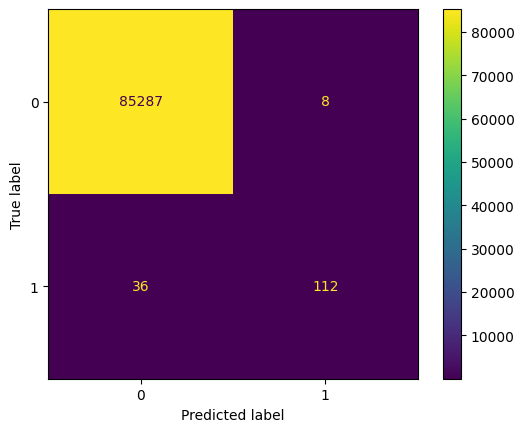

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb);

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

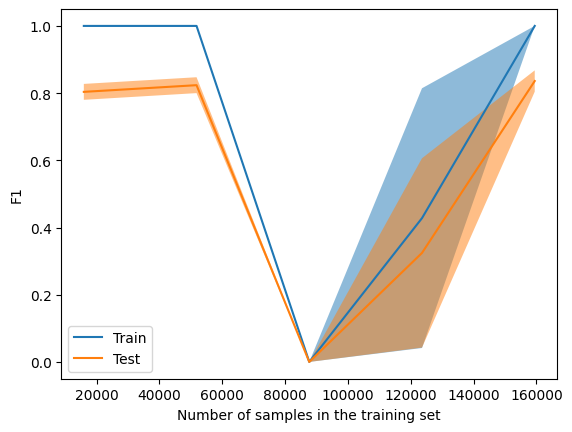

In [ ]:
display = LearningCurveDisplay.from_estimator(
    xgb,
    X_train,
    y_train,
    cv=cv,
    score_type="both",
    scoring="f1",
    n_jobs=-1
)

On detecte un problème de surapprentissage.

In [ ]:
pred = xgb.predict(X_test)

In [ ]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.58      0.84      0.69       148

    accuracy                           1.00     85443
   macro avg       0.79      0.92      0.84     85443
weighted avg       1.00      1.00      1.00     85443



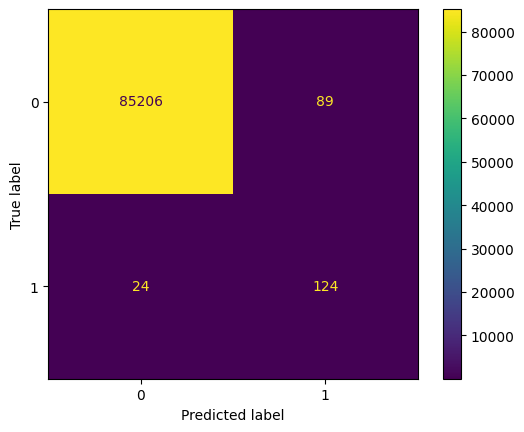

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, pred);

#Deep Learning

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))


model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))


model.add(Dense(16, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
stop = EarlyStopping(monitor='val_loss', patience=10, verbose=1, restore_best_weights=True)

In [ ]:
model.fit(X_train_scaled, y_train,
          validation_data=(X_test_scaled, y_test),
          epochs=1000, batch_size=32, callbacks=[stop])

Epoch 1/1000
6231/6231 ━━━━━━━━━━━━━━━━━━━━ 47s 6ms/step - accuracy: 0.9815 - loss: 0.0558 - val_accuracy: 0.9993 - val_loss: 0.0091
Epoch 2/1000
6231/6231 ━━━━━━━━━━━━━━━━━━━━ 46s 7ms/step - accuracy: 0.9985 - loss: 0.0073 - val_accuracy: 0.9992 - val_loss: 0.0151
Epoch 3/1000
6231/6231 ━━━━━━━━━━━━━━━━━━━━ 44s 7ms/step - accuracy: 0.9987 - loss: 0.0062 - val_accuracy: 0.9992 - val_loss: 0.0156
Epoch 4/1000
6231/6231 ━━━━━━━━━━━━━━━━━━━━ 44s 7ms/step - accuracy: 0.9989 - loss: 0.0052 - val_accuracy: 0.9993 - val_loss: 0.0166
Epoch 5/1000
6231/6231 ━━━━━━━━━━━━━━━━━━━━ 109s 11ms/step - accuracy: 0.9991 - loss: 0.0049 - val_accuracy: 0.9993 - val_loss: 0.0189
Epoch 6/1000
6231/6231 ━━━━━━━━━━━━━━━━━━━━ 66s 11ms/step - accuracy: 0.9991 - loss: 0.0045 - val_accuracy: 0.9993 - val_loss: 0.0208
Epoch 7/1000
6231/6231 ━━━━━━━━━━━━━━━━━━━━ 74s 9ms/step - accuracy: 0.9991 - loss: 0.0048 - val_accuracy: 0.9993 - val_loss: 0.0224
Epoch 8/1000
6231/6231 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - accurac

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,469 (181.52 KB)

 Trainable params: 15,329 (59.88 KB)

 Non-trainable params: 480 (1.88 KB)

 Optimizer params: 30,660 (119.77 KB)

In [ ]:
loss = pd.DataFrame(model.history.history)

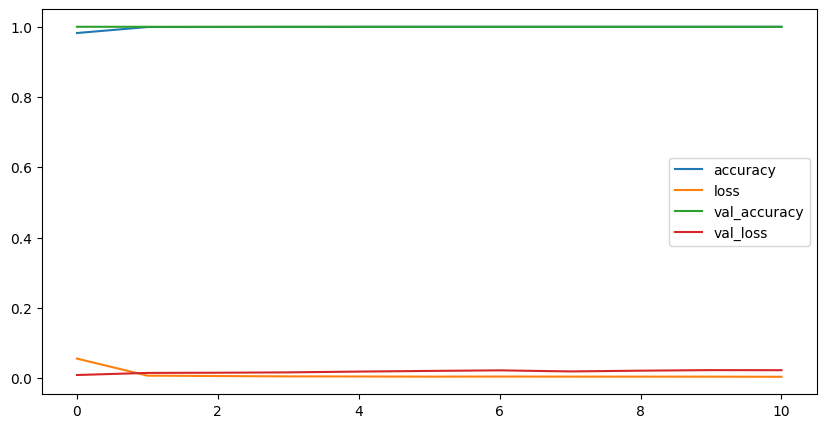

In [ ]:
loss.plot(figsize=(10, 5));

In [ ]:
model.evaluate(X_test_scaled, y_test)

2671/2671 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9993 - loss: 0.0091


[0.00911470502614975, 0.9992860555648804]

In [ ]:
y_pred_dl = np.round(model.predict(X_test_scaled))

2671/2671 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step


In [ ]:
print(classification_report(y_test, y_pred_dl))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.80      0.78      0.79       148

    accuracy                           1.00     85443
   macro avg       0.90      0.89      0.90     85443
weighted avg       1.00      1.00      1.00     85443



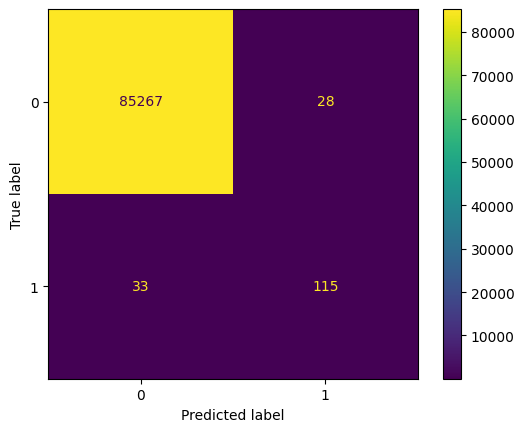

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dl);

In [92]:
#Importance des variables en se basant sur XGBoost vu que ses résultas sont mieux que les autres
feature_importance = pd.DataFrame({'Feature': X_train.columns, 'Importance': xgb.feature_importances_})
feature_importance = feature_importance.sort_values('Importance', ascending=True)

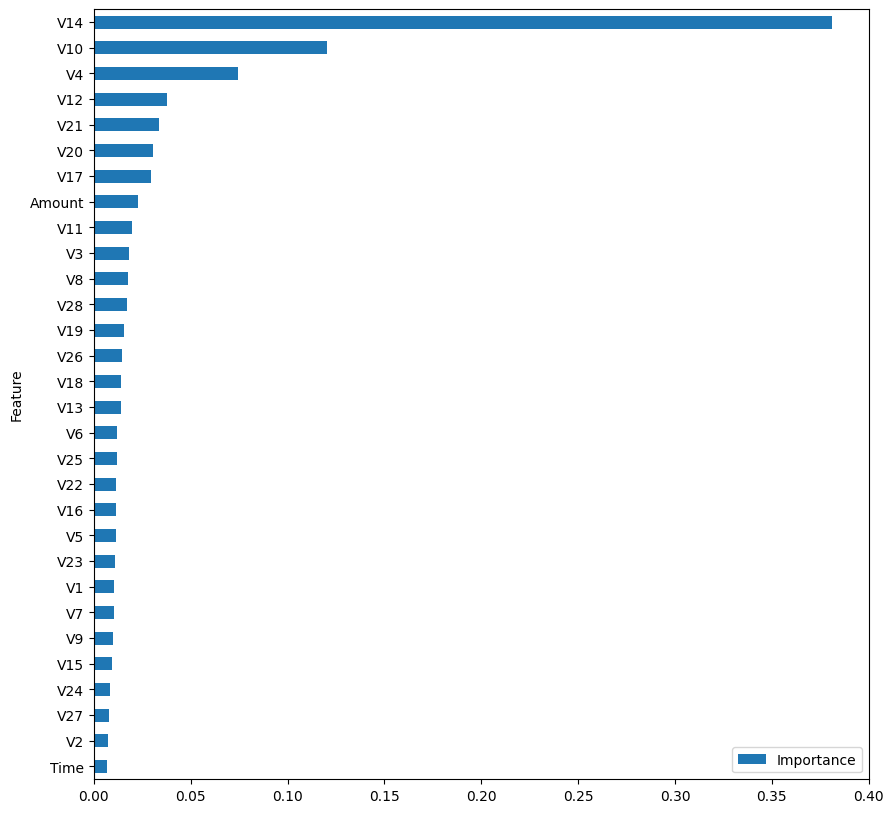

In [93]:
feature_importance.plot(kind='barh', x='Feature', figsize=(10, 10));

Si on se fie à notre graphe, on constate que la variable qui intervient le plus ou qui influence le plus le modèle est la variable `V14`